## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro 'm' de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Carga datos y representa la serie

In [3]:
df = pd.read_csv('data/AirPassengers.csv', parse_dates = ['date'])
df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    144 non-null    datetime64[us]
 1   value   144 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 2.4 KB


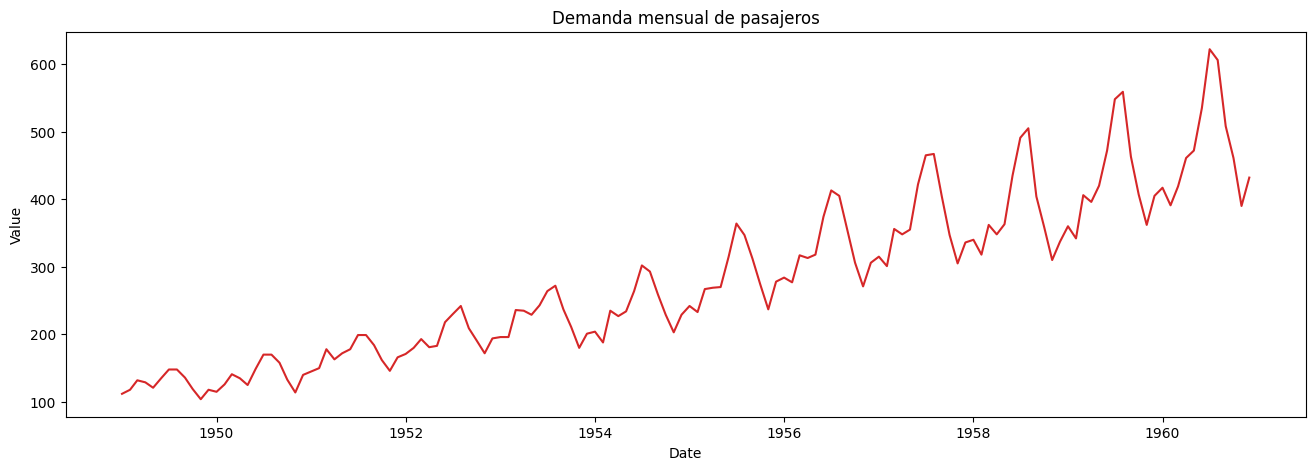

In [5]:
def plot_df(df, x, y, title='', xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df['date'], y=df['value'], title='Demanda mensual de pasajeros') 

Comprobamos si hay estacionalidad:

In [ ]:
import numpy as np
import matplotlib as mpl

# Import Data
df.reset_index(inplace=True)

# Prepare data
df['year'] = [d.year for d in df.date]
df['month'] = [d.strftime('%b') for d in df.date]
years = df['year'].unique()

# Prep Colors
np.random.seed(100)
mycolors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(years), replace=False)

# Draw Plot
plt.figure(figsize=(16,12), dpi= 80)
for i, y in enumerate(years):
    if i > 0:        
        plt.plot('month', 'value', data=df.loc[df.year==y, :], color=mycolors[i], label=y)
        plt.text(df.loc[df.year==y, :].shape[0]-.9, df.loc[df.year==y, 'value'][-1:].values[0], y, fontsize=12, color=mycolors[i])

# Decoration
plt.gca().set(xlim=(-0.3, 11), ylim=(2, 30), ylabel='$Pasajeros$', xlabel='$Fecha$')
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot of Passenger demand", fontsize=20)
plt.show()

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

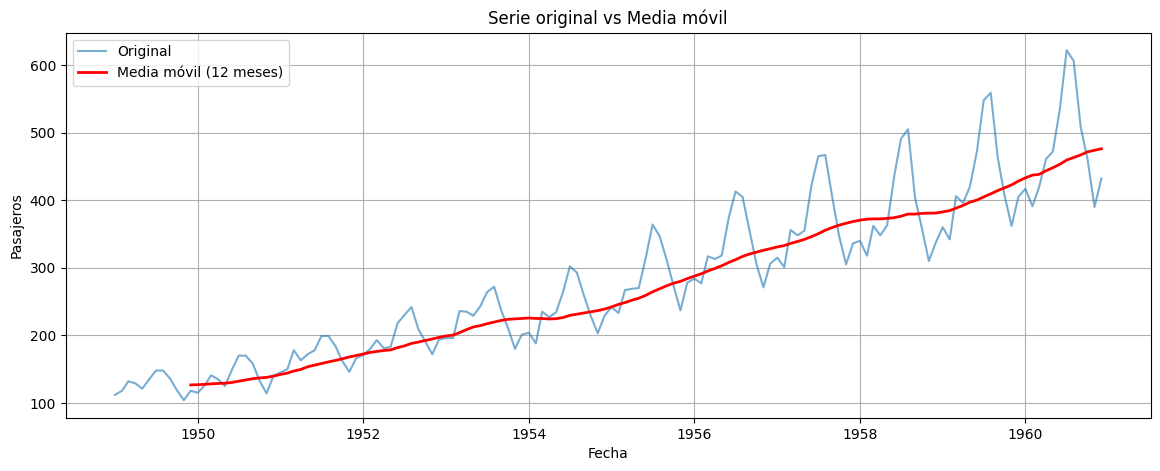

In [6]:
df['rolling_mean'] = df['value'].rolling(window=12).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['value'], alpha=0.6, label='Original')
plt.plot(df['date'], df['rolling_mean'], color='red', linewidth=2, label='Media móvil (12 meses)')
plt.title('Serie original vs Media móvil')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True);

## 3. Comprueba de manera estadística si la serie es o no estacionaria.

In [7]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF Test
adf = adfuller(df['value'])
print('=== ADF Test ===')
print(f'p-valor: {adf[1]:.4f}')
print('→ No estacionaria' if adf[1] > 0.05 else '→ Estacionaria')

# KPSS Test
kpss_stat = kpss(df['value'], regression='c')
print('\n=== KPSS Test ===')
print(f'p-valor: {kpss_stat[1]:.4f}')
print('→ No estacionaria' if kpss_stat[1] < 0.05 else '→ Estacionaria')

=== ADF Test ===
p-valor: 0.9919
→ No estacionaria

=== KPSS Test ===
p-valor: 0.0100
→ No estacionaria


## 4. Aplica una transformación logarítmica

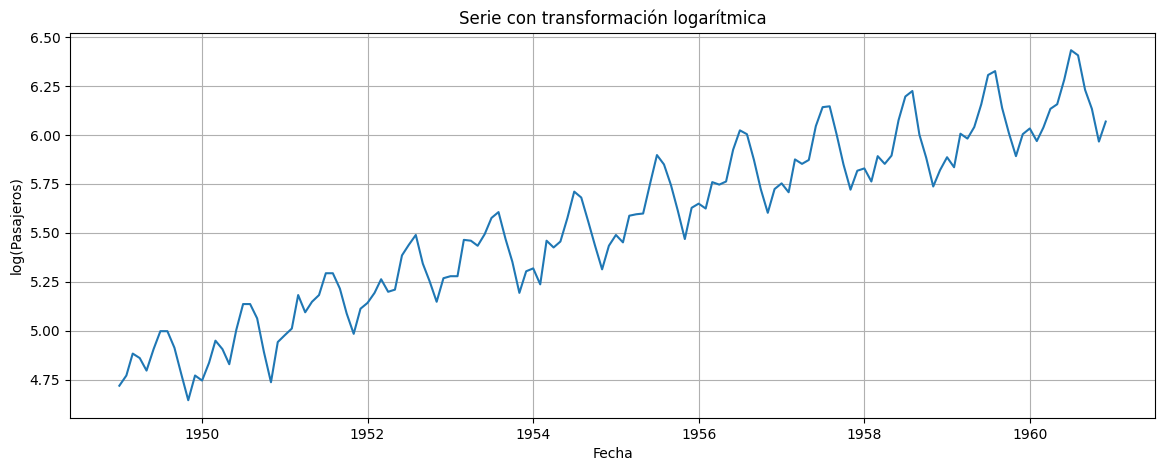

In [8]:
df['log_value'] = np.log(df['value'])

plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['log_value'])
plt.title('Serie con transformación logarítmica')
plt.xlabel('Fecha')
plt.ylabel('log(Pasajeros)')
plt.grid(True);

Se aprecia mucho mejor la estacionalidad. La transformación logarítmica estabiliza la varianza creciente (los picos de verano son cada vez más grandes). Esto facilita que el modelado posterior con ARIMA.

## 5. Divide en train y test. Guarda 20 muestras para test.

In [9]:
train = df[:-20]
test = df[-20:]

print(train.shape)
print(test.shape)

(124, 4)
(20, 4)


## 6. Crea tu primer modelo ARIMA

Con el modelo SARIMA, ya tenemos en cuenta la estacionalidad de 12 meses

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error


# SARIMA(1,1,1)(1,1,1,12) — el m=12 captura la estacionalidad anual
# Apuntes para entender parámetros
# order=(p, d, q) — parte no estacional:
# p=1 → usa 1 lag anterior para predecir
# d=1 → diferencia la serie 1 vez para eliminar la tendencia
# q=1 → corrige el error del paso anterior (media móvil)

# seasonal_order=(P, D, Q, m) — parte estacional:
# P=1, D=1, Q=1 → lo mismo que arriba pero a nivel estacional
# m=12 → el patrón estacional se repite cada 12 meses
model = SARIMAX(train['log_value'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12))

result = model.fit(disp=False)
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          log_value   No. Observations:                  124
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 206.547
Date:                            Sun, 10 May 2026   AIC                           -403.095
Time:                                    19:41:06   BIC                           -389.547
Sample:                                         0   HQIC                          -397.599
                                            - 124                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2268      0.258      0.880      0.379      -0.278       0.732
ma.L1         -0.5636      0.228   

## 7. Representa en una gráfica los datos de test y tus predicciones.

In [11]:
# Predicciones sobre el período de test
pred_log = result.forecast(20)

# El resultado sale en logarítmico, hay que transformar de nuevo
predictions = np.exp(pred_log)
y_real = test['value'].values

# Métricas
mae = mean_absolute_error(y_real, predictions)
rmse = np.sqrt(np.mean((y_real - predictions) ** 2))
print(f'\nMAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')


MAE:  18.81
RMSE: 20.49


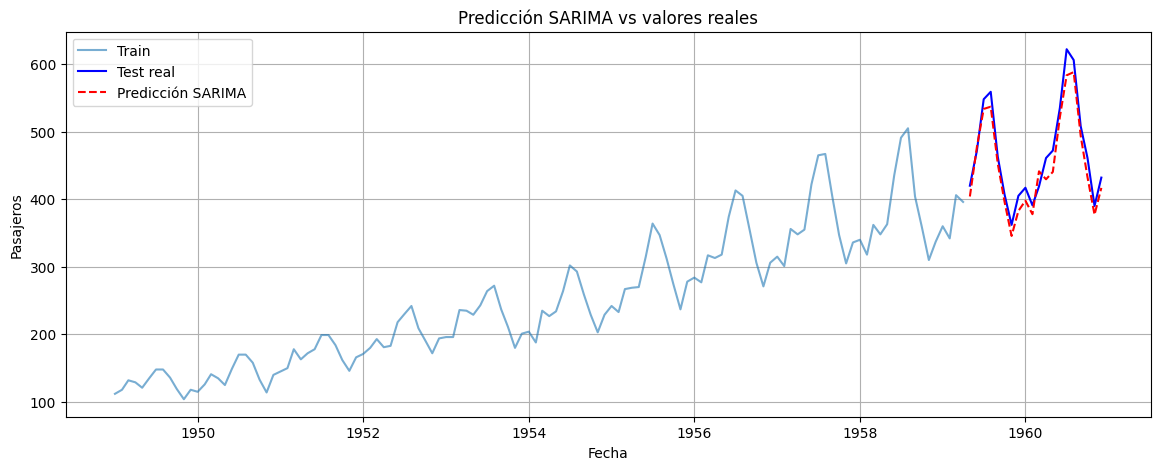

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(train['date'], train['value'], label='Train', alpha=0.6)
plt.plot(test['date'], test['value'], label='Test real', color='blue')
plt.plot(test['date'].values, predictions, label='Predicción SARIMA', color='red', linestyle='--')
plt.title('Predicción SARIMA vs valores reales')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True);

## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Crear features de lags
def create_lag_features(series, n_lags=12):
    df_lags = pd.DataFrame({'y': series})
    for i in range(1, n_lags + 1):
        df_lags[f'lag_{i}'] = series.shift(i)
    return df_lags.dropna()

df_lags = create_lag_features(df['log_value'])

X = df_lags.drop(columns='y')
y = df_lags['y']

X_train = X.iloc[:-20]
y_train = y.iloc[:-20]
X_test  = X.iloc[-20:]
y_test  = y.iloc[-20:]

for name, model in [('Decision Tree', DecisionTreeRegressor(random_state=42)),
                     ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42))]:
    model.fit(X_train, y_train)
    preds = np.exp(model.predict(X_test))
    y_real = np.exp(y_test.values)
    mae  = mean_absolute_error(y_real, preds)
    rmse = np.sqrt(np.mean((y_real - preds) ** 2))
    print(f"{name} → MAE: {mae:.2f} | RMSE: {rmse:.2f}")

Decision Tree → MAE: 43.30 | RMSE: 53.85
Random Forest → MAE: 38.56 | RMSE: 55.80


Tal y como esperábamos, SARIMA suele ser mejor que Decision Tree y Random Forest en series temporales con estacionalidad clara, porque estos modelos no entienden beien el aspepcto secuencial del tiempo, solo analizan números. SARIMA está diseñado específicamente para este tipo de datos.